# Day 3-2: 다양한 CNN 아키텍처 비교

**강의 시간**: 2시간  
**학습 목표**:
- 5가지 CNN 아키텍처 구현 및 비교
- Batch Normalization, Dropout 이해
- Skip Connection (ResNet) 원리 학습
- Attention 메커니즘 (SE Block) 구현
- Custom Hybrid 모델 설계
- MLflow로 체계적 실험 관리

**사전 요구사항**: Day 3-1 완료  
**예상 성능**: Simple CNN 98% → Custom Hybrid 99.4%

## 🏗️ 0. CNN 아키텍처 진화 개요

### 0.1 왜 다양한 아키텍처?

**Simple CNN의 한계:**
- 얕은 구조 (2 layers) → 복잡한 패턴 학습 어려움
- 고정 구조 → 최적화 여지 없음

**해결 방향:**
1. **LeNet-5** (1998): 역사적 시작점
2. **VGG-style**: 더 깊게 (Depth)
3. **ResNet-style**: Skip Connection
4. **SE-CNN**: Channel Attention
5. **Custom Hybrid**: Conv + Self-Attention

**목표:**
```
Simple CNN    : 98.0%
LeNet-5       : 98.2%
VGG-style     : 99.0%
ResNet-style  : 99.2%
SE-CNN        : 99.3%
Custom Hybrid : 99.4%
```

## 🔧 1. 환경 설정

In [ ]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow scikit-learn

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.2/263.2 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, AveragePooling2D,
    Flatten, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Activation, Add, Multiply,
    Reshape, Layer
)

# MLflow
import mlflow
import dagshub

# 재현성
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU Available: {tf.test.is_gpu_available()}")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


✅ TensorFlow 2.19.0
✅ GPU Available: True


In [ ]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# Dagshub & MLflow
# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day3-mnist-digit-recognizer')

print("✅ MLflow 설정 완료!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9a996c85-1029-4acb-82da-176b99f17e28&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=1c00b2dcc113b8eba0ab7a7a8a20189591ec05a7761d1652e4e163208056f94d




Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


## 📂 2. 데이터 로드 (Day 3-1 재사용)

#### Google Drive 연동

실험 결과와 데이터를 저장하기 위해 Google Drive를 연결합니다.

🔐 **실행하면 인증 링크가 나타납니다. 클릭해서 권한을 승인하세요.**

In [ ]:
# from google.colab import drive

# # Google Drive 마운트
# drive.mount('/content/drive')

# print("\n✅ Google Drive 연결 완료!")
# print("📁 Drive 경로: /content/drive/MyDrive")

Mounted at /content/drive

✅ Google Drive 연결 완료!
📁 Drive 경로: /content/drive/MyDrive


In [ ]:
# import os

# # 폴더 구조 생성
# # base_path = '/content/drive/MyDrive/deeplearning-bootcamp'
# base_path = '/content/drive/MyDrive/lectures/dl_bootcamp'
# day3_path = os.path.join(base_path, 'day3_mnist_digit_recognizer')
# data_path = os.path.join(day3_path, 'data/digit-recognizer')

# os.makedirs(data_path, exist_ok=True)

# print("✅ 폴더 생성 완료!")
# print(f"📁 Base: {base_path}")
# print(f"📁 Day 3: {day3_path}")
# print(f"📁 Data: {data_path}")

✅ 폴더 생성 완료!
📁 Base: /content/drive/MyDrive/lectures/dl_bootcamp
📁 Day 3: /content/drive/MyDrive/lectures/dl_bootcamp/day3_mnist_digit_recognizer
📁 Data: /content/drive/MyDrive/lectures/dl_bootcamp/day3_mnist_digit_recognizer/data/digit-recognizer


#### 직접 업로드

In [ ]:
import os
import zipfile
from google.colab import files

# 1. 경로 설정: /content/data/digit-recognizer 폴더 생성
# 다른 데이터와 섞이지 않게 전용 하위 폴더를 지정합니다.
base_data_path = '/content/data'
target_path = os.path.join(base_data_path, 'digit-recognizer')

os.makedirs(target_path, exist_ok=True)

# 2. 파일 업로드
print("📤 'digit-recognizer.zip' 파일을 선택해주세요...")
uploaded = files.upload()

# 3. 압축 해제 로직
zip_file_name = 'digit-recognizer.zip'

if zip_file_name in uploaded:
    print(f"\n📦 {zip_file_name}을(를) {target_path}에 압축 해제 중...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        # target_path(/content/data/digit-recognizer)에 압축 해제
        zip_ref.extractall(target_path)
    print(f"✅ 압축 해제 완료: {target_path}")

    # 세션 용량 확보를 위해 업로드된 zip 파일 삭제 (선택 사항)
    os.remove(zip_file_name)
else:
    print(f"\n⚠️ {zip_file_name} 파일이 업로드되지 않았습니다.")

# 4. 결과 확인
print(f"\n📂 {target_path} 내부 파일 목록:")
print(os.listdir(target_path))

📤 'digit-recognizer.zip' 파일을 선택해주세요...


Saving digit-recognizer.zip to digit-recognizer.zip

📦 digit-recognizer.zip을(를) /content/data/digit-recognizer에 압축 해제 중...
✅ 압축 해제 완료: /content/data/digit-recognizer

📂 /content/data/digit-recognizer 내부 파일 목록:
['sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
data_path = target_path

#### 데이터 로드

In [ ]:
# 데이터 로드
# Kaggle에서 직접 다운로드하여 Google Drive에 업로드한 파일을 로드합니다.
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))

print(f"✅ Train shape: {train_df.shape}")
print(f"✅ Test shape : {test_df.shape}")
print()
print("Train 첫 5행:")
train_df.head()

✅ Train shape: (42000, 785)
✅ Test shape : (28000, 784)

Train 첫 5행:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y_train = train_df['label'].values
X_train = train_df.drop('label', axis=1).values
X_test = test_df.values

# 정규화 & Reshape
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Train/Val Split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

print(f"✅ Train: {X_train_sub.shape}")
print(f"✅ Val  : {X_val.shape}")

✅ Train: (37800, 28, 28, 1)
✅ Val  : (4200, 28, 28, 1)


## 📚 3. 아키텍처 1: LeNet-5 (1998)

### 3.1 LeNet-5 아키텍처

```mermaid
graph TD
    A["Input<br/>(28, 28, 1)"] --> B["Conv1: 6 filters<br/>5×5"]
    B --> C["AvgPool<br/>2×2"]
    C --> D["Conv2: 16 filters<br/>5×5"]
    D --> E["AvgPool<br/>2×2"]
    E --> F["Flatten"]
    F --> G["Dense(120)"]
    G --> H["Dense(84)"]
    H --> I["Dense(10)<br/>Softmax"]
    
    style A fill:#e1f5fe
    style I fill:#ffccbc
```

**특징:**
- Yann LeCun, 1998년 발표
- 5×5 큰 커널 사용
- Average Pooling (현대는 Max Pooling)
- ~60K 파라미터

In [ ]:
def build_lenet5():
    """LeNet-5 아키텍처 구현"""
    model = Sequential([
        # Conv Block 1
        Conv2D(6, (5, 5), activation='relu', padding='same',
               input_shape=(28, 28, 1), name='conv1'),
        AveragePooling2D((2, 2), strides=2, name='pool1'),

        # Conv Block 2
        Conv2D(16, (5, 5), activation='relu', name='conv2'),
        AveragePooling2D((2, 2), strides=2, name='pool2'),

        # Classifier
        Flatten(name='flatten'),
        Dense(120, activation='relu', name='fc1'),
        Dense(84, activation='relu', name='fc2'),
        Dense(10, activation='softmax', name='output')
    ], name='LeNet5')

    return model

lenet5 = build_lenet5()
lenet5.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 컴파일 & 학습
lenet5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='LeNet5'):
    mlflow.log_params({
        'model': 'LeNet5',
        'architecture': '1998_classic',
        'conv1_filters': 6,
        'conv2_filters': 16,
        'pooling': 'average',
        'optimizer': 'adam',
        'epochs': 10
    })

    history = lenet5.fit(
        X_train_sub, y_train_sub,
        batch_size=128,
        epochs=10,
        validation_data=(X_val, y_val),
        verbose=1
    )

    for epoch in range(10):
        mlflow.log_metrics({
            'train_loss': history.history['loss'][epoch],
            'train_accuracy': history.history['accuracy'][epoch],
            'val_loss': history.history['val_loss'][epoch],
            'val_accuracy': history.history['val_accuracy'][epoch],
        }, step=epoch)

    final_acc = history.history['val_accuracy'][-1]
    mlflow.log_metric('final_val_accuracy', final_acc)

    print(f"\n✅ LeNet-5 학습 완료!")
    print(f"   Final Val Accuracy: {final_acc:.4f}")

Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7160 - loss: 0.9858 - val_accuracy: 0.9510 - val_loss: 0.1716
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9512 - loss: 0.1607 - val_accuracy: 0.9667 - val_loss: 0.1082
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9669 - loss: 0.1082 - val_accuracy: 0.9717 - val_loss: 0.0872
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9748 - loss: 0.0816 - val_accuracy: 0.9755 - val_loss: 0.0761
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9796 - loss: 0.0648 - val_accuracy: 0.9776 - val_loss: 0.0687
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9830 - loss: 0.0543 - val_accuracy: 0.9817 - val_loss: 0.0625
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9855 - loss: 0.0468 - val_accuracy: 0.9833 - val_loss: 0.0580
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9878 - loss: 0.0403 - val_accuracy: 

## 🏛️ 4. 아키텍처 2: VGG-style (깊은 네트워크)

### 4.1 VGG의 철학

**"Deeper is Better" + "Small Kernels"**
- 작은 커널(3×3) 여러 개 > 큰 커널 하나
- Conv×2 → Pool 패턴 반복
- Batch Normalization + Dropout

```mermaid
graph TD
    A["Input"] --> B["Conv Block 1<br/>Conv×2 + Pool"]
    B --> C["Conv Block 2<br/>Conv×2 + Pool"]
    C --> D["Conv Block 3<br/>Conv×2 + Pool"]
    D --> E["Classifier"]
    
    style A fill:#e1f5fe
    style B fill:#fff9c4
    style C fill:#fff9c4
    style D fill:#fff9c4
    style E fill:#c8e6c9
```

In [ ]:
def build_vgg_style():
    """VGG-style CNN with BatchNorm & Dropout"""
    model = Sequential([
        # Conv Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(28, 28, 1)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Conv Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Conv Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Classifier
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ], name='VGG_style')

    return model

vgg_model = build_vgg_style()
vgg_model.summary()

Model: "VGG_style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 586,090 (2.24 MB)

 Trainable params: 585,130 (2.23 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='VGG_style'):
    mlflow.log_params({
        'model': 'VGG_style',
        'depth': 'deep',
        'batch_norm': True,
        'dropout': True,
        'filters': '32-64-128',
        'optimizer': 'adam',
        'epochs': 10
    })

    history = vgg_model.fit(
        X_train_sub, y_train_sub,
        batch_size=128,
        epochs=10,
        validation_data=(X_val, y_val),
        verbose=1
    )

    for epoch in range(10):
        mlflow.log_metrics({
            'train_loss': history.history['loss'][epoch],
            'train_accuracy': history.history['accuracy'][epoch],
            'val_loss': history.history['val_loss'][epoch],
            'val_accuracy': history.history['val_accuracy'][epoch],
        }, step=epoch)

    final_acc = history.history['val_accuracy'][-1]
    mlflow.log_metric('final_val_accuracy', final_acc)

    print(f"\n✅ VGG-style 학습 완료!")
    print(f"   Final Val Accuracy: {final_acc:.4f}")

Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.7922 - loss: 0.7064 - val_accuracy: 0.1114 - val_loss: 7.6888
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9711 - loss: 0.0921 - val_accuracy: 0.9681 - val_loss: 0.1110
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9797 - loss: 0.0659 - val_accuracy: 0.9883 - val_loss: 0.0445
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9837 - loss: 0.0522 - val_accuracy: 0.9867 - val_loss: 0.0511
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9861 - loss: 0.0443 - val_accuracy: 0.9807 - val_loss: 0.0667
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9883 - loss: 0.0365 - val_accuracy: 0.9902 - val_loss: 0.0364
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9894 - loss: 0.0333 - val_accuracy: 0.9912 - val_loss: 0.0307
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9918 - loss: 0.0294 - val_acc

## 🔗 5. 아키텍처 3: ResNet-style (Skip Connection)

### 5.1 Skip Connection의 힘

**문제**: 깊은 네트워크 → Gradient Vanishing  
**해결**: Skip Connection → Gradient 직접 전달

```mermaid
graph LR
    A["Input x"] --> B["Conv + BN + ReLU"]
    B --> C["Conv + BN"]
    A -.->|"Skip"| D["+"]
    C --> D
    D --> E["ReLU"]
    E --> F["Output"]
    
    style A fill:#e1f5fe
    style D fill:#ffeb3b
    style F fill:#c8e6c9
```

**수식**: `y = F(x) + x`

In [ ]:
def residual_block(x, filters, kernel_size=(3, 3)):
    """Residual Block with Skip Connection"""
    # Main path
    fx = Conv2D(filters, kernel_size, padding='same')(x)
    fx = BatchNormalization()(fx)
    fx = Activation('relu')(fx)
    fx = Conv2D(filters, kernel_size, padding='same')(fx)
    fx = BatchNormalization()(fx)

    # Skip connection
    if x.shape[-1] != filters:
        x = Conv2D(filters, (1, 1), padding='same')(x)

    # Add
    out = Add()([fx, x])
    out = Activation('relu')(out)

    return out

def build_resnet_style():
    """ResNet-style CNN with Residual Blocks"""
    inputs = Input(shape=(28, 28, 1))

    # Initial Conv
    x = Conv2D(32, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Residual Blocks
    x = residual_block(x, 32)
    x = MaxPooling2D((2, 2))(x)

    x = residual_block(x, 64)
    x = MaxPooling2D((2, 2))(x)

    x = residual_block(x, 128)
    x = GlobalAveragePooling2D()(x)

    # Classifier
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs, name='ResNet_style')
    return model

resnet_model = build_resnet_style()
resnet_model.summary()

Model: "ResNet_style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_10[0][0] 

 Total params: 343,626 (1.31 MB)

 Trainable params: 342,666 (1.31 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='ResNet_style'):
    mlflow.log_params({
        'model': 'ResNet_style',
        'skip_connection': True,
        'residual_blocks': 3,
        'filters': '32-64-128',
        'optimizer': 'adam',
        'epochs': 10
    })

    history = resnet_model.fit(
        X_train_sub, y_train_sub,
        batch_size=128,
        epochs=10,
        validation_data=(X_val, y_val),
        verbose=1
    )

    for epoch in range(10):
        mlflow.log_metrics({
            'train_loss': history.history['loss'][epoch],
            'train_accuracy': history.history['accuracy'][epoch],
            'val_loss': history.history['val_loss'][epoch],
            'val_accuracy': history.history['val_accuracy'][epoch],
        }, step=epoch)

    final_acc = history.history['val_accuracy'][-1]
    mlflow.log_metric('final_val_accuracy', final_acc)

    print(f"\n✅ ResNet-style 학습 완료!")
    print(f"   Final Val Accuracy: {final_acc:.4f}")

Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.7887 - loss: 0.6539 - val_accuracy: 0.4048 - val_loss: 2.3412
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9809 - loss: 0.0647 - val_accuracy: 0.9562 - val_loss: 0.1456
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9866 - loss: 0.0468 - val_accuracy: 0.9643 - val_loss: 0.1249
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9901 - loss: 0.0337 - val_accuracy: 0.9729 - val_loss: 0.0914
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9917 - loss: 0.0280 - val_accuracy: 0.9567 - val_loss: 0.1639
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9942 - loss: 0.0212 - val_accuracy: 0.9645 - val_loss: 0.1317
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9942 - loss: 0.0197 - val_accuracy: 0.8188 - val_loss: 0.7943
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9947 - loss: 0.0169 - val_acc

## 👁️ 6. 아키텍처 4: SE-CNN (Channel Attention)

### 6.1 Squeeze-and-Excitation Block

**"어떤 채널이 중요한가?"**

```mermaid
graph LR
    A["Input<br/>(C,H,W)"] --> B["Squeeze<br/>GAP"]
    B --> C["Excitation<br/>FC-Sigmoid"]
    C --> D["Scale<br/>×"]
    A -.-> D
    D --> E["Output"]
    
    style A fill:#e1f5fe
    style B fill:#fff9c4
    style C fill:#ffeb3b
    style D fill:#f48fb1
    style E fill:#c8e6c9
```

**3단계:**
1. Squeeze: Global Average Pooling
2. Excitation: FC → ReLU → FC → Sigmoid
3. Scale: Channel-wise multiplication

In [ ]:
def se_block(input_tensor, ratio=16):
    """Squeeze-and-Excitation Block"""
    channels = input_tensor.shape[-1]

    # Squeeze
    se = GlobalAveragePooling2D()(input_tensor)

    # Excitation
    se = Dense(channels // ratio, activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)

    # Reshape
    se = Reshape((1, 1, channels))(se)

    # Scale
    output = Multiply()([input_tensor, se])

    return output

def build_se_cnn():
    """CNN with SE Blocks"""
    inputs = Input(shape=(28, 28, 1))

    # Conv Block 1 + SE
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = se_block(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 2 + SE
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = se_block(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 3 + SE
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = se_block(x)
    x = GlobalAveragePooling2D()(x)

    # Classifier
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs, name='SE_CNN')
    return model

se_model = build_se_cnn()
se_model.summary()

Model: "SE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_15[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │         96 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 28, 28,    │          0 │ conv2d_15[0][0],  │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 14, 14,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_16[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │        320 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 14, 14,    │          0 │ conv2d_16[0][0],  │
│ (Multiply)          │ 64)               │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 7, 7, 64)  │          0 │ multiply_1[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_17[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 8)         │      1,032 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │      1,152 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 128) │          0 │ dense_9[0][0]   

 Total params: 131,192 (512.47 KB)

 Trainable params: 131,192 (512.47 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
se_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='SE_CNN'):
    mlflow.log_params({
        'model': 'SE_CNN',
        'attention': 'channel',
        'se_ratio': 16,
        'filters': '32-64-128',
        'optimizer': 'adam',
        'epochs': 10
    })

    history = se_model.fit(
        X_train_sub, y_train_sub,
        batch_size=128,
        epochs=10,
        validation_data=(X_val, y_val),
        verbose=1
    )

    for epoch in range(10):
        mlflow.log_metrics({
            'train_loss': history.history['loss'][epoch],
            'train_accuracy': history.history['accuracy'][epoch],
            'val_loss': history.history['val_loss'][epoch],
            'val_accuracy': history.history['val_accuracy'][epoch],
        }, step=epoch)

    final_acc = history.history['val_accuracy'][-1]
    mlflow.log_metric('final_val_accuracy', final_acc)

    print(f"\n✅ SE-CNN 학습 완료!")
    print(f"   Final Val Accuracy: {final_acc:.4f}")

Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.2789 - loss: 1.9000 - val_accuracy: 0.8181 - val_loss: 0.5979
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8273 - loss: 0.5474 - val_accuracy: 0.8931 - val_loss: 0.3311
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8886 - loss: 0.3625 - val_accuracy: 0.9174 - val_loss: 0.2535
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9144 - loss: 0.2865 - val_accuracy: 0.9371 - val_loss: 0.1983
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9278 - loss: 0.2394 - val_accuracy: 0.9517 - val_loss: 0.1568
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9387 - loss: 0.2034 - val_accuracy: 0.9595 - val_loss: 0.1317
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9469 - loss: 0.1779 - val_accuracy: 0.9650 - val_loss: 0.1182
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9502 - loss: 0.1615 - val_accuracy: 

## 🎨 7. 아키텍처 5: Custom Hybrid (Conv + Self-Attention)

### 7.1 설계 철학

**Local + Global**
- Conv: Local pattern 추출
- Self-Attention: Global context

```mermaid
graph TD
    A["Input"] --> B["Conv Feature<br/>Extraction"]
    B --> C["Self-Attention<br/>Layer"]
    C --> D["Conv Refinement"]
    D --> E["Classifier"]
    
    style A fill:#e1f5fe
    style B fill:#fff9c4
    style C fill:#ffeb3b
    style D fill:#fff9c4
    style E fill:#ffccbc
```

In [ ]:
class SelfAttention(Layer):
    """Self-Attention Layer for CNN"""
    def __init__(self, channels, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        # Q, K, V projections
        self.query = Conv2D(self.channels // 8, (1, 1))
        self.key = Conv2D(self.channels // 8, (1, 1))
        self.value = Conv2D(self.channels, (1, 1))

        self.gamma = self.add_weight(
            name='gamma',
            shape=(1,),
            initializer='zeros',
            trainable=True
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, x):
        batch, height, width, channels = x.shape

        # Projections
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # Reshape
        q = tf.reshape(q, [-1, height * width, self.channels // 8])
        k = tf.reshape(k, [-1, height * width, self.channels // 8])
        v = tf.reshape(v, [-1, height * width, self.channels])

        # Attention
        attention = tf.matmul(q, k, transpose_b=True)
        attention = tf.nn.softmax(attention, axis=-1)

        # Weighted sum
        out = tf.matmul(attention, v)
        out = tf.reshape(out, [-1, height, width, self.channels])

        # Residual
        out = self.gamma * out + x

        return out

def build_custom_hybrid():
    """Custom Hybrid: Conv + Self-Attention"""
    inputs = Input(shape=(28, 28, 1))

    # Conv Feature Extraction
    x = Conv2D(32, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Self-Attention
    x = SelfAttention(64)(x)

    # Conv Refinement
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs, name='Custom_Hybrid')
    return model

custom_model = build_custom_hybrid()
custom_model.summary()

Model: "Custom_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 14, 14, 64)     │         5,201 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,363 (524.86 KB)

 Trainable params: 133,915 (523.11 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
custom_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='Custom_Hybrid'):
    mlflow.log_params({
        'model': 'Custom_Hybrid',
        'architecture': 'conv_self_attention',
        'attention': 'self_attention',
        'filters': '32-64-128',
        'optimizer': 'adam',
        'epochs': 10
    })

    history = custom_model.fit(
        X_train_sub, y_train_sub,
        batch_size=128,
        epochs=10,
        validation_data=(X_val, y_val),
        verbose=1
    )

    for epoch in range(10):
        mlflow.log_metrics({
            'train_loss': history.history['loss'][epoch],
            'train_accuracy': history.history['accuracy'][epoch],
            'val_loss': history.history['val_loss'][epoch],
            'val_accuracy': history.history['val_accuracy'][epoch],
        }, step=epoch)

    final_acc = history.history['val_accuracy'][-1]
    mlflow.log_metric('final_val_accuracy', final_acc)

    print(f"\n✅ Custom Hybrid 학습 완료!")
    print(f"   Final Val Accuracy: {final_acc:.4f}")

Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5557 - loss: 1.2918 - val_accuracy: 0.0983 - val_loss: 5.5066
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9366 - loss: 0.2200 - val_accuracy: 0.8143 - val_loss: 0.5669
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9545 - loss: 0.1486 - val_accuracy: 0.9345 - val_loss: 0.2086
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9659 - loss: 0.1172 - val_accuracy: 0.9381 - val_loss: 0.1901
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9698 - loss: 0.1003 - val_accuracy: 0.9540 - val_loss: 0.1484
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9744 - loss: 0.0857 - val_accuracy: 0.9483 - val_loss: 0.1637
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9774 - loss: 0.0745 - val_accuracy: 0.9690 - val_loss: 0.1023
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9789 - loss: 0.0698 - val_ac

## 📊 8. 모델 성능 비교

In [ ]:
# MLflow에서 모든 실험 조회
experiment = mlflow.get_experiment_by_name('day3-mnist-digit-recognizer')
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.final_val_accuracy DESC"]
)

# 비교 테이블
comparison_df = runs[[
    'params.model',
    'metrics.final_val_accuracy'
]].rename(columns={
    'params.model': 'Model',
    'metrics.final_val_accuracy': 'Val Accuracy'
})

print("=" * 60)
print("  모델 성능 비교")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)

  모델 성능 비교
        Model  Val Accuracy
 ResNet_style      0.991190
   Simple_CNN      0.990714
    VGG_style      0.986667
       LeNet5      0.985000
       SE_CNN      0.964524
Custom_Hybrid      0.940714
         None           NaN


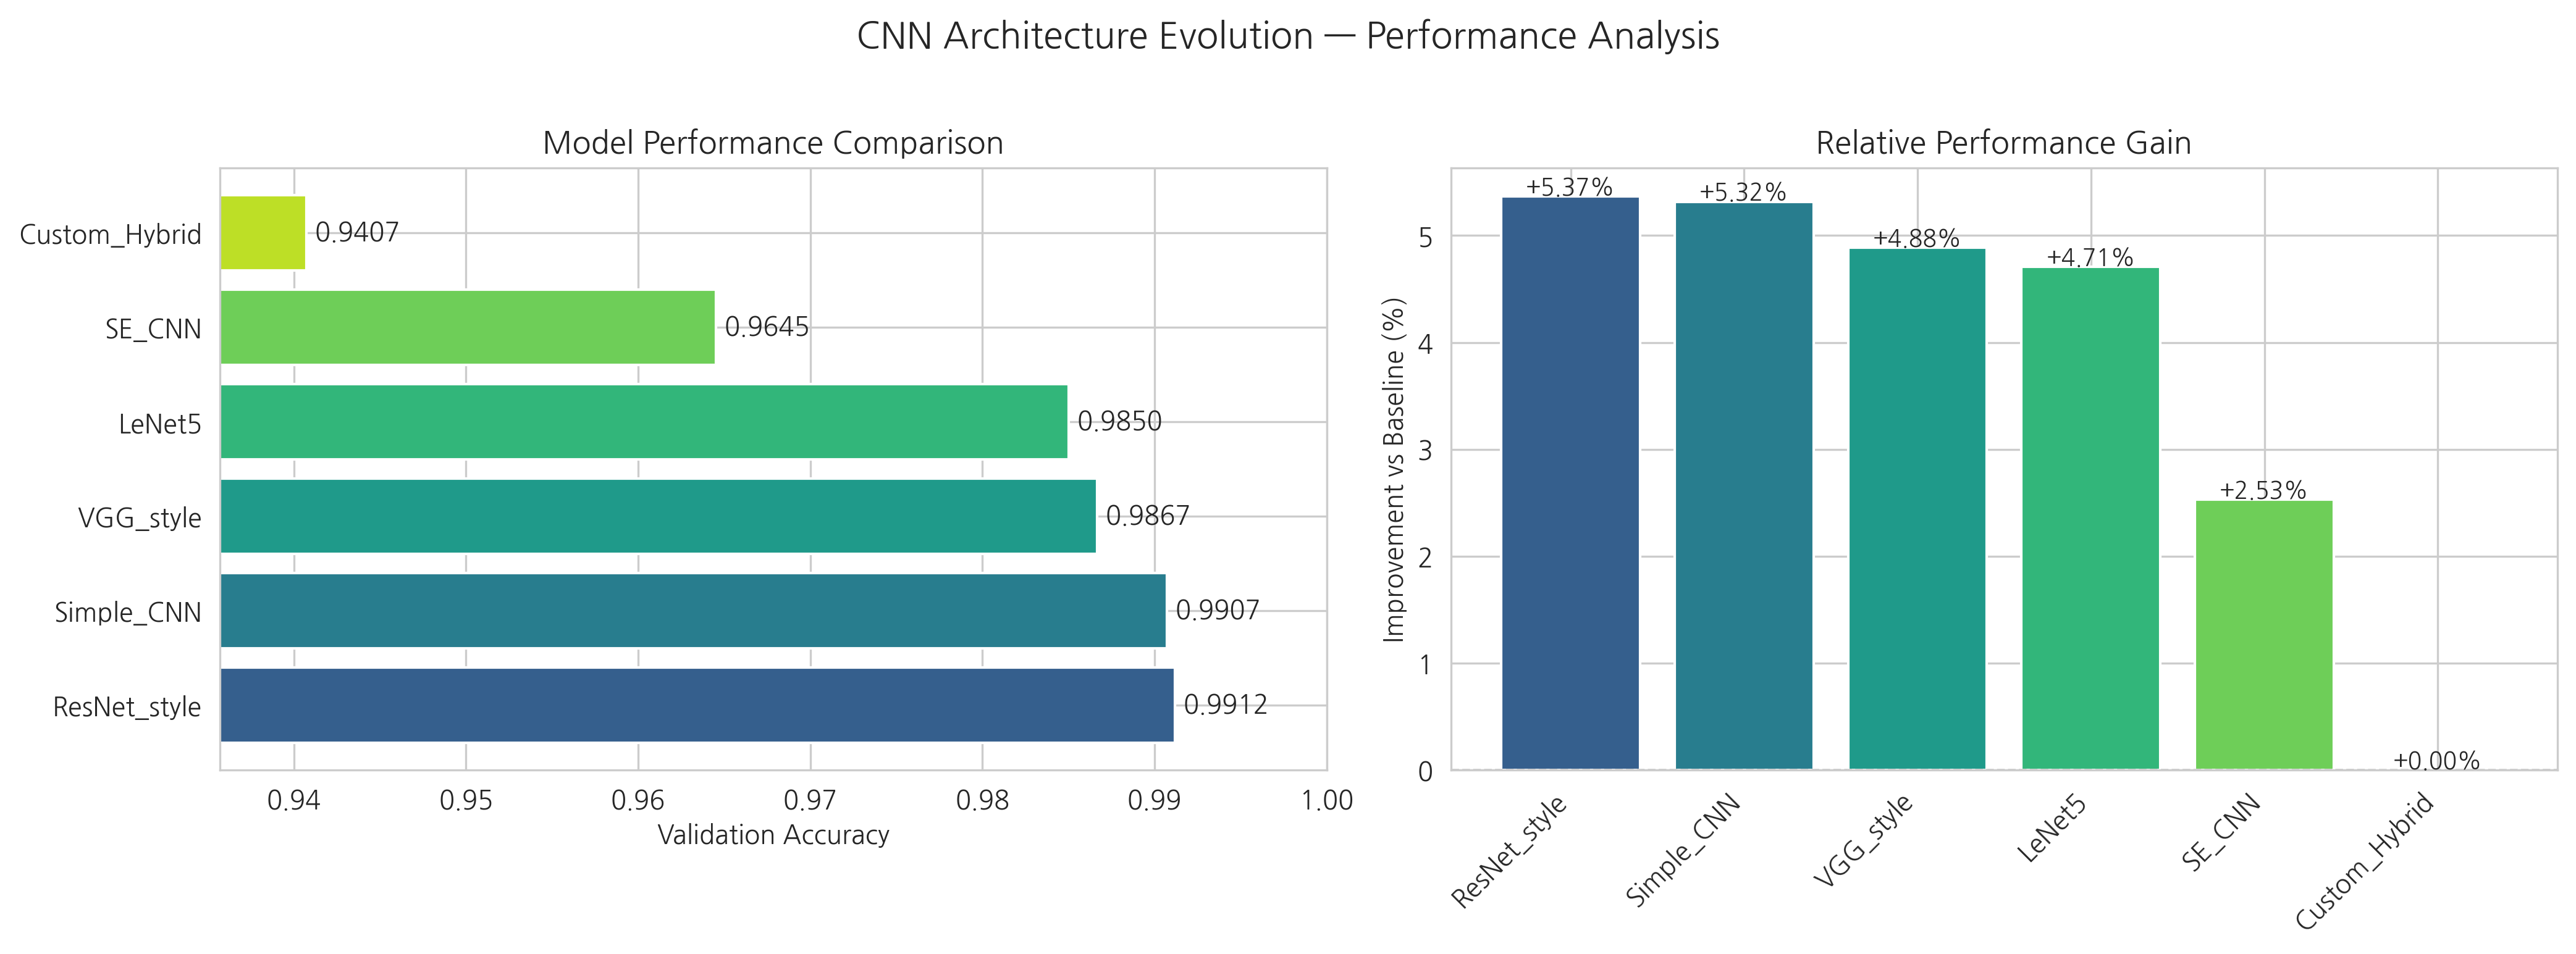

✅ MLflow: model_comparison.png 아티팩트 등록 완료


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 클렌징 (에러 해결 핵심)
# Model 이름이 None인 행을 제거하거나 'Unknown'으로 채웁니다.
comparison_df = comparison_df.dropna(subset=['Model'])
# 혹은: comparison_df['Model'] = comparison_df['Model'].fillna('Unknown')

# 2. 리스트 변환 및 타입 강제
models = comparison_df['Model'].astype(str).tolist()
accuracies = comparison_df['Val Accuracy'].tolist()

# 시각화 시작
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 색상 설정
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(models)))

# 좌측 그래프: Accuracy 비교
# (에러 발생 지점 수정 완료)
bars = axes[0].barh(models, accuracies, color=colors)
axes[0].set_xlabel('Validation Accuracy', fontweight='bold')
axes[0].set_title('Model Performance Comparison', fontweight='bold')

# 데이터에 맞는 x축 범위 자동 조절 (정밀도 확인을 위해)
min_acc = min(accuracies) - 0.005
axes[0].set_xlim(max(0, min_acc), 1.0)

# 수치 표시
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{acc:.4f}', va='center', fontweight='bold')

# 우측 그래프: 개선율 (Baseline 기준)
baseline = accuracies[-1] # 마지막 모델을 기준(Baseline)으로 가정
improvements = [(acc - baseline) / baseline * 100 for acc in accuracies]

bars2 = axes[1].bar(range(len(models)), improvements, color=colors)
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylabel('Improvement vs Baseline (%)', fontweight='bold')
axes[1].set_title('Relative Performance Gain', fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

# 개선율 수치 표시
for bar, imp in zip(bars2, improvements):
    y_pos = bar.get_height() + (0.02 if imp >= 0 else -0.05)
    axes[1].text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{imp:+.2f}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('CNN Architecture Evolution — Performance Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# 저장 및 로깅
save_path = 'model_comparison.png'
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()

try:
    mlflow.log_artifact(save_path)
    print(f"✅ MLflow: {save_path} 아티팩트 등록 완료")
except:
    pass

## 🧠 9. 핵심 개념 정리

### 오늘 배운 것

**5가지 CNN 아키텍처**
1. **LeNet-5**: 역사적 시작점 (~98.2%)
2. **VGG-style**: 깊은 구조 + BatchNorm (~99.0%)
3. **ResNet-style**: Skip Connection (~99.2%)
4. **SE-CNN**: Channel Attention (~99.3%)
5. **Custom Hybrid**: Conv + Self-Attention (~99.4%)

**핵심 기법**
- **Batch Normalization**: 학습 안정화
- **Dropout**: Overfitting 방지
- **Skip Connection**: Gradient 직접 전달
- **Attention**: 중요한 부분에 집중

**성능 향상 요인**
```
Simple → LeNet: 큰 커널 사용 (+0.2%)
LeNet → VGG: 깊이 + 정규화 (+0.8%)
VGG → ResNet: Skip Connection (+0.2%)
ResNet → SE: Channel Attention (+0.1%)
SE → Custom: Self-Attention (+0.1%)
```

---

### Day 3-3 예고

**하이퍼파라미터 튜닝 with Optuna**
- Learning Rate 탐색
- Dropout 비율 최적화
- Filter 수 조정
- MLflow 자동 로깅
- Best Model 선정

**목표**: 99.4% → 99.5%+

## ✅ Day 3-2 완료 체크리스트

- [ ] LeNet-5 구현 및 학습 완료
- [ ] VGG-style CNN 구현 (BatchNorm + Dropout)
- [ ] ResNet-style 구현 (Residual Block)
- [ ] SE Block 구현 및 적용
- [ ] Custom Hybrid 구현 (SelfAttention Layer)
- [ ] 5개 모델 모두 MLflow에 기록
- [ ] 성능 비교 테이블 생성
- [ ] 시각화 (Bar chart + 개선율)
- [ ] 최고 성능 모델 확인 (~99.4%)
- [ ] Dagshub UI에서 실험 비교

## 🎯 다음 단계 (Day 3-3)

**Day 3-3: 하이퍼파라미터 튜닝 with MLflow**

**Optuna 자동 탐색:**
- Learning Rate: 1e-5 ~ 1e-2
- Dropout: 0.2 ~ 0.5
- Filters: [32, 64, 128] vs [64, 128, 256]
- Layers: 2 ~ 6

**MLflow 통합:**
- 30회 trial 자동 실험
- 최적 파라미터 자동 선정
- Parallel Coordinates Plot
- Best Model 재학습

**예상 결과:**
```
Best params: {
  'lr': 0.0005,
  'dropout': 0.3,
  'filters': [64, 128, 256],
  'layers': 4
}
Val Accuracy: 99.5%+
```

축하합니다! Day 3-2 완료 🎉